In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from collections import Counter
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, classification_report

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import joblib


In [128]:
#koll wa7d y4t8l 3ly cell yktb esmo fo2yha 34an nkon fhmyn bss
#mohamed ayman
#7awll koll wa7d w hwa by4t8l y4r7 kill stry 34an hyfr2 m3ana fel a5r w7na bn2fl project w 3ady 3rby aw english aw franko bss keyboard english bss f3dhaly

In [129]:
#mohamed ayman


dataset = ['FD001', 'FD002', 'FD003', 'FD004'] #=>dol el sub dataset names
rul_cap = 125  # da t2dr t2ol bn3ml cliping y3ny ay 7aga akbr myn 125 keda healthy ay 7aga as8r not healthy w 125 bzat 34an kant mogoda fel pdf

#el t7t da wel t7to bss bn7ot labels 3l data 34an w5dnha mlha4 labels
index_cols = ['unit_number', 'time_cycles'] #=> unit_number da esm aw rkm motor , time_cycle da y3ny dy r7la rkm kam lmotor el lyh unit_number mo3yn  , fkr fyha akn fy wa7d esmo ahmed w gry awl mra keda unit_number ahmed time_cycle 1 b3d keda ahmed gry tany keda da row gdyd w unit_number ahmed wel time_cycle s3tha 2
setting_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3'] #=> dol bywsfo 7ala el motor kan bytyr fyha m4 motor nfso (2rtfa3 , sor3to , tyar kann days 3l bnzyd add ehh) dol mohmyn 34an sensor ht5tlf 2rayto 7sb el settings dy 7ta lw el motor slym
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]  # =>dy for loop 3dya b7ot 3ly koll column fyh 2ryat sensor esm lsensor w mrkmhom 34an akyb m4 h5o4 23rf koll sensor mel 21 by3ml eh
all_cols = index_cols + setting_cols + sensor_cols  # => hna 5las 3mlt fyha list fyha labels lkoll columns




In [130]:
all_cols

['unit_number',
 'time_cycles',
 'op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [131]:
#mohamed ayman
def load_raw(path): #=> dy function bdll m3ml read lkol dataset b2ydy hya function w h3ml for loop 3ly asamy dataset el fo2 wkeda hkon 3mlt call lyha

    data = pd.read_csv(path, sep=r'\s+', header=None) # => \s dy y3ny coll columns mtfr2a b space 3dya w header = no 34an zy m2olt fel bdaya data mlha4 header w keda dlw2ty homa 26 column myn 0 -> 25 mtrkmyn keda 0,1,2,3,..,24,25
    data = data.iloc[:, :26]    # (:) dy m3naha 5od koll rows , (:26) m3naha 5od awl 25 column bss b2a
    data.columns = all_cols
    return data
#keda ay 7d hyb3d data ll load_raw hyrg3ha labeld data

def compute_train_rul(data):  # => function dy bta5od el motor da fdlo add eh w2t abl myboz
    max_cycle = data.groupby('unit_number')['time_cycles'].transform('max') #hna ana 3ayz a3rf max bta3 koll motor w a3ml colum gdyd esmo max_cycle w a7ot fyh max da fbdl m3ml for loop agyb max bta3 koll wa7d w b3d keda n7oto fel column fda 3mlha w angz w2t
    data['rul'] = max_cycle - data['time_cycles'] #hna bkoll bsata gbt lkol motor fdlo add eh w2t abl myboz w wd7a
    data['rul'] = data['rul'].clip(upper=rul_cap) #hna 3mlt el clip el 2olt 3nha fy cell 1 fy 4ab3 str code
    return data


def compute_test_rul(data, rul_path):  #hna hta5od data el tl3t mel load_raw el m3mola lltest el hwa fel a5r htkon full test dataset bss m3molha cutoff 3nd 7ta el motor faile 3ndha da m4 ana el 3mlha da data keda fa rul_path da file so8yr by2ol lkol motor kan fy kam cycle b2ya abl mytl3oh 3n el5dma fel a5r htl3 test data mtzbta w fyha column by2olk lkol motor fadl lyh kam lfa f3ln m4 zy m7sbtha fel fumction el fo2 dy
    true_rul_at_end = pd.read_csv(rul_path, header=None, names=['rul_end']) #bload data rul el 2olt 3lyha w bdyha esm llcolum 3ady
    true_rul_at_end['unit_number'] = true_rul_at_end.index + 1  #hna brkm bss bdl myn 0,1,2,3 5ltha 1,2,3,4 34an tkon wak3ya

    max_cycle = data.groupby('unit_number')['time_cycles'].max().reset_index() # by2olk lkol motor 3ndo max cycle kam
    max_cycle.columns = ['unit_number', 'max_cycle'] # da labels

    data = data.merge(max_cycle, on='unit_number', how='left') # hna by5ly doll motor ytrbt bel max cycle bt3to
    data = data.merge(true_rul_at_end, on='unit_number', how='left') # nfs el fkra bss m3 true

    data['rul'] = data['rul_end'] + (data['max_cycle'] - data['time_cycles']) #azon wd7a
    data['rul'] = data['rul'].clip(upper=rul_cap) #clip brdo
    data = data.drop(columns=['max_cycle', 'rul_end']) #dol kano lzmthom fy 7sabat bss 8yr keda drop
    return data




In [132]:
import os

DATA_DIR = "../data"  # لأن النوت بوك جوه notebook/ والداتا جوه data/

train_frames = []
test_frames = []

for ds in dataset:
    train_df = load_raw(os.path.join(DATA_DIR, f'train_{ds}.txt'))
    train_df = compute_train_rul(train_df)
    train_df['dataset'] = ds
    train_df['n_conditions'] = 6 if ds in ['FD002', 'FD004'] else 1
    train_df['n_fault_modes'] = 2 if ds in ['FD003', 'FD004'] else 1
    train_frames.append(train_df)

    test_df = load_raw(os.path.join(DATA_DIR, f'test_{ds}.txt'))
    test_df = compute_test_rul(test_df, os.path.join(DATA_DIR, f'RUL_{ds}.txt'))
    test_df['dataset'] = ds
    test_df['n_conditions'] = 6 if ds in ['FD002', 'FD004'] else 1
    test_df['n_fault_modes'] = 2 if ds in ['FD003', 'FD004'] else 1
    test_frames.append(test_df)

train_all = pd.concat(train_frames, ignore_index=True)
test_all = pd.concat(test_frames, ignore_index=True)

train_all['global_unit_id'] = train_all['dataset'] + '_' + train_all['unit_number'].astype(str)
test_all['global_unit_id'] = test_all['dataset'] + '_' + test_all['unit_number'].astype(str)

In [133]:
print("Train shape:", train_all.shape)
print("Test shape:", test_all.shape)
print(train_all['dataset'].value_counts())

Train shape: (160359, 31)
Test shape: (104897, 31)
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64


In [134]:
train_all.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,125,FD001,1,1,FD001_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,125,FD001,1,1,FD001_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,125,FD001,1,1,FD001_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,125,FD001,1,1,FD001_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,125,FD001,1,1,FD001_1


In [135]:
test_all.head()
#keda hamdla 3l slama m3ana data koll da fel 3ady kan bykon pd.read_csv("./esm el data") bss rbna y5llna youssef

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,392,2388,100.0,38.86,23.3735,125,FD001,1,1,FD001_1
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,393,2388,100.0,39.02,23.3916,125,FD001,1,1,FD001_1
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,393,2388,100.0,39.08,23.4166,125,FD001,1,1,FD001_1
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,391,2388,100.0,39.00,23.3737,125,FD001,1,1,FD001_1
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,390,2388,100.0,38.99,23.4130,125,FD001,1,1,FD001_1


In [136]:
train_all.shape

(160359, 31)

In [137]:
test_all.shape

(104897, 31)

In [138]:
for col in train_all.columns:
  print(train_all[col].value_counts())
  print("_____________________")
  #mlha4 lzma ana 3arf

unit_number
96     1305
88     1288
10     1241
55     1221
94     1205
       ... 
250     184
256     163
253     149
258     143
252     135
Name: count, Length: 260, dtype: int64
_____________________
time_cycles
1      709
2      709
3      709
4      709
5      709
      ... 
539      1
540      1
541      1
542      1
543      1
Name: count, Length: 543, dtype: int64
_____________________
op_setting_1
 0.0004    1465
 0.0002    1441
 0.0001    1414
 0.0005    1410
 0.0006    1409
           ... 
-0.0087       1
-0.0079       1
 0.0086       1
 0.0078       1
-0.0085       1
Name: count, Length: 670, dtype: int64
_____________________
op_setting_2
 0.8400    23617
 0.0000    13484
 0.2500     8824
 0.6200     8811
 0.7000     8731
           ...  
 0.7020      248
 0.6220      213
 0.0020      208
 0.2520      195
-0.0006       62
Name: count, Length: 111, dtype: int64
_____________________
op_setting_3
100.0    143218
60.0      17141
Name: count, dtype: int64
___________________

In [139]:
for col in train_all.columns:
  print(train_all[col].unique)
  print("_____________________")

<bound method Series.unique of 0           1
1           1
2           1
3           1
4           1
         ... 
160354    249
160355    249
160356    249
160357    249
160358    249
Name: unit_number, Length: 160359, dtype: int64>
_____________________
<bound method Series.unique of 0           1
1           2
2           3
3           4
4           5
         ... 
160354    251
160355    252
160356    253
160357    254
160358    255
Name: time_cycles, Length: 160359, dtype: int64>
_____________________
<bound method Series.unique of 0         -0.0007
1          0.0019
2         -0.0043
3          0.0007
4         -0.0019
           ...   
160354     9.9998
160355     0.0028
160356     0.0029
160357    35.0046
160358    42.0030
Name: op_setting_1, Length: 160359, dtype: float64>
_____________________
<bound method Series.unique of 0        -0.0004
1        -0.0003
2         0.0003
3         0.0000
4        -0.0002
           ...  
160354    0.2500
160355    0.0015
160356    0.0000
1

In [140]:
train_all.isnull().sum()

unit_number       0
time_cycles       0
op_setting_1      0
op_setting_2      0
op_setting_3      0
sensor_1          0
sensor_2          0
sensor_3          0
sensor_4          0
sensor_5          0
sensor_6          0
sensor_7          0
sensor_8          0
sensor_9          0
sensor_10         0
sensor_11         0
sensor_12         0
sensor_13         0
sensor_14         0
sensor_15         0
sensor_16         0
sensor_17         0
sensor_18         0
sensor_19         0
sensor_20         0
sensor_21         0
rul               0
dataset           0
n_conditions      0
n_fault_modes     0
global_unit_id    0
dtype: int64

In [141]:
train_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   unit_number     160359 non-null  int64  
 1   time_cycles     160359 non-null  int64  
 2   op_setting_1    160359 non-null  float64
 3   op_setting_2    160359 non-null  float64
 4   op_setting_3    160359 non-null  float64
 5   sensor_1        160359 non-null  float64
 6   sensor_2        160359 non-null  float64
 7   sensor_3        160359 non-null  float64
 8   sensor_4        160359 non-null  float64
 9   sensor_5        160359 non-null  float64
 10  sensor_6        160359 non-null  float64
 11  sensor_7        160359 non-null  float64
 12  sensor_8        160359 non-null  float64
 13  sensor_9        160359 non-null  float64
 14  sensor_10       160359 non-null  float64
 15  sensor_11       160359 non-null  float64
 16  sensor_12       160359 non-null  float64
 17  sensor_13       16035

In [142]:
train_all.describe() #

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul,n_conditions,n_fault_modes
count,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,...,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000
mean,105.553758,123.331338,17.211973,0.410004,95.724344,485.840890,597.361022,1467.035653,1260.956434,9.894999,...,9.054747,0.025185,360.698801,2273.754039,98.389146,25.942709,15.565700,90.182029,4.585954,1.536103
std,72.867325,83.538146,16.527988,0.367938,12.359044,30.420388,42.478516,118.175261,136.300073,4.265554,...,0.751581,0.004997,31.021430,142.513114,4.656270,11.691422,7.015067,41.241036,2.251829,0.498696
min,1.000000,1.000000,-0.008700,-0.000600,60.000000,445.000000,535.480000,1242.670000,1023.770000,3.910000,...,8.156300,0.020000,302.000000,1915.000000,84.930000,10.160000,6.010500,0.000000,1.000000,1.000000
25%,44.000000,57.000000,0.001300,0.000200,100.000000,449.440000,549.960000,1357.360000,1126.830000,5.480000,...,8.439250,0.020000,332.000000,2212.000000,100.000000,14.330000,8.601300,56.000000,1.000000,1.000000
50%,89.000000,114.000000,19.998100,0.620000,100.000000,489.050000,605.930000,1492.810000,1271.740000,9.350000,...,9.030100,0.030000,367.000000,2319.000000,100.000000,24.920000,14.953500,113.000000,6.000000,2.000000
75%,164.000000,173.000000,35.001500,0.840000,100.000000,518.670000,642.340000,1586.590000,1402.200000,14.620000,...,9.344200,0.030000,392.000000,2388.000000,100.000000,38.820000,23.294600,125.000000,6.000000,2.000000
max,260.000000,543.000000,42.008000,0.842000,100.000000,518.670000,645.110000,1616.910000,1441.490000,14.620000,...,11.066900,0.030000,400.000000,2388.000000,100.000000,39.890000,23.950500,125.000000,6.000000,2.000000


In [143]:
train_all.dtypes.value_counts()

float64    22
int64       7
str         2
Name: count, dtype: int64

In [144]:
print(train_all["sensor_1"].std())

30.420388148059974


In [145]:
for col in all_cols:
    print(f"{col}: coff_of_var : {(train_all[col].std())/(train_all[col].mean())}")
    print("______________________________")

unit_number: coff_of_var : 0.6903337848598046
______________________________
time_cycles: coff_of_var : 0.677347274547103
______________________________
op_setting_1: coff_of_var : 0.960261108141514
______________________________
op_setting_2: coff_of_var : 0.8974023365720343
______________________________
op_setting_3: coff_of_var : 0.1291107753954873
______________________________
sensor_1: coff_of_var : 0.06261389021386951
______________________________
sensor_2: coff_of_var : 0.07111029163352249
______________________________
sensor_3: coff_of_var : 0.08055377545484706
______________________________
sensor_4: coff_of_var : 0.10809261054682168
______________________________
sensor_5: coff_of_var : 0.4310818329139981
______________________________
sensor_6: coff_of_var : 0.4467210591519112
______________________________
sensor_7: coff_of_var : 0.4840681919226078
______________________________
sensor_8: coff_of_var : 0.06263732629678662
______________________________
sensor_9: coff_of

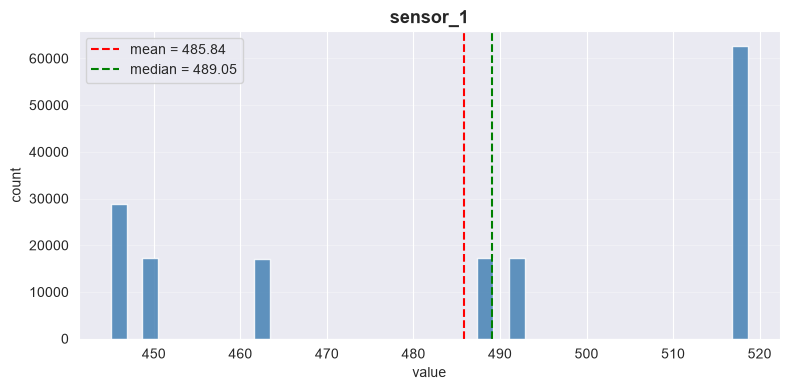

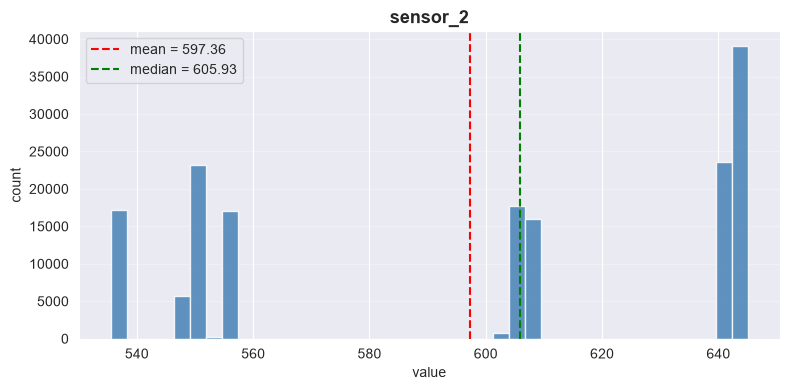

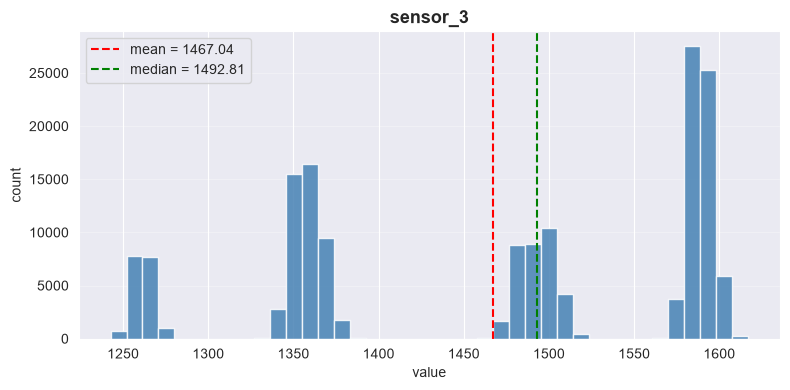

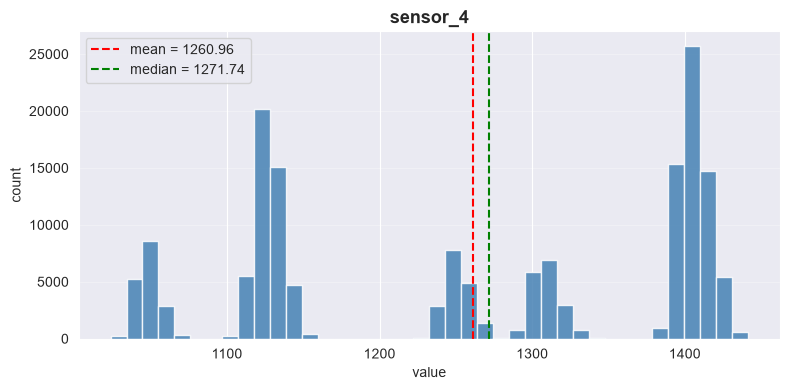

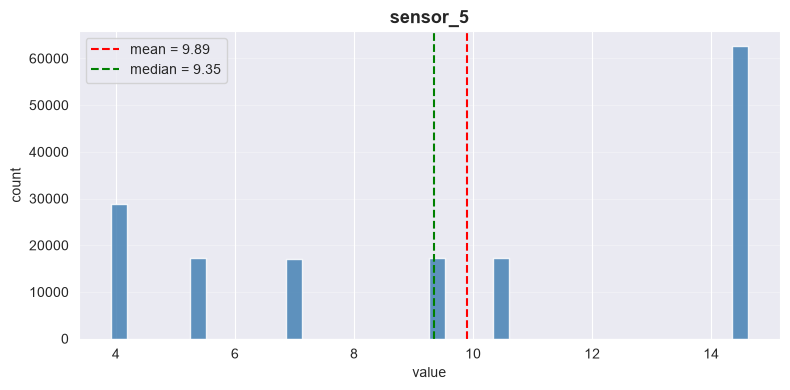

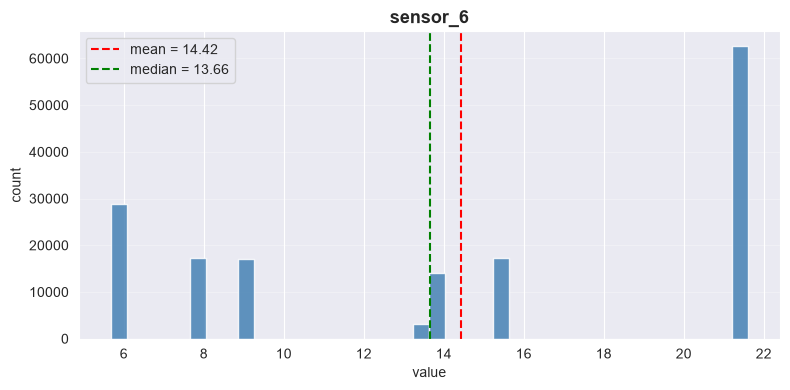

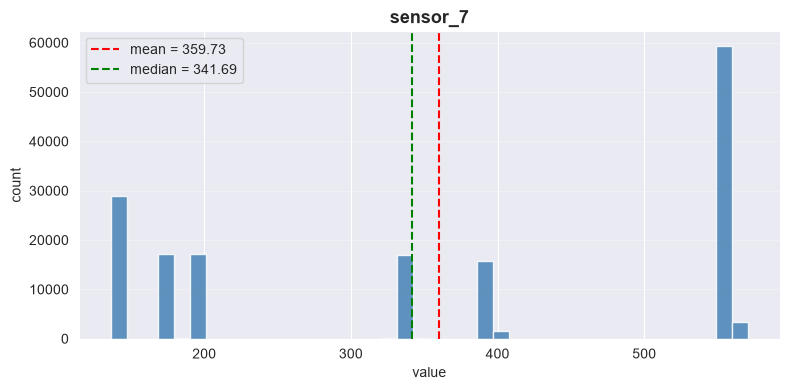

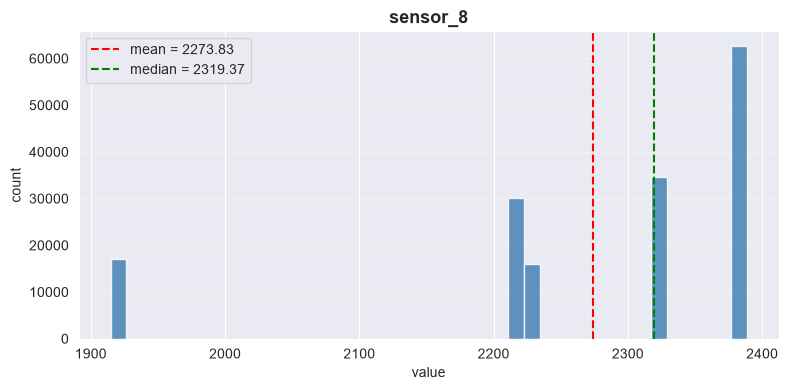

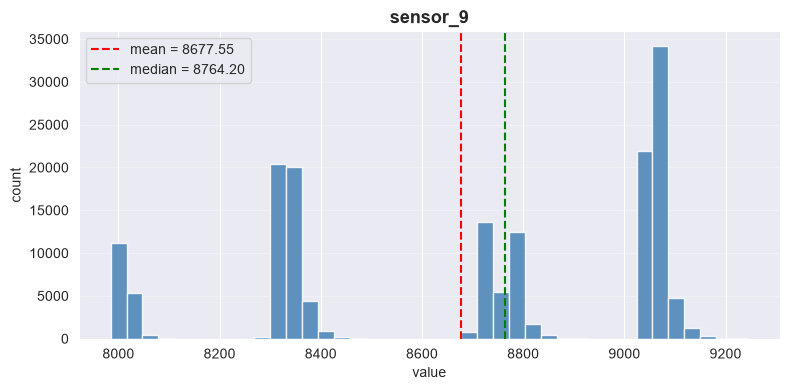

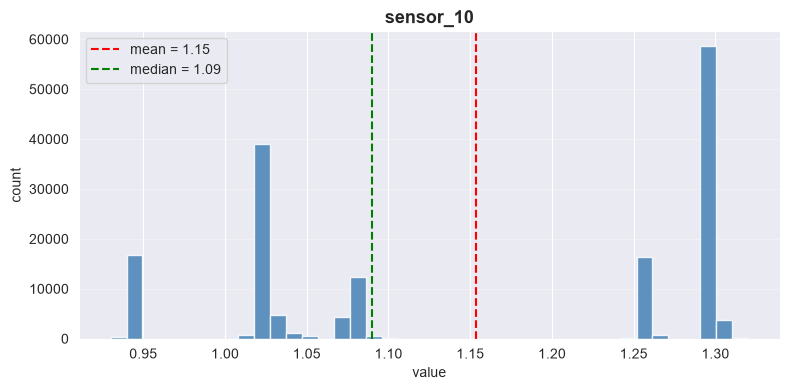

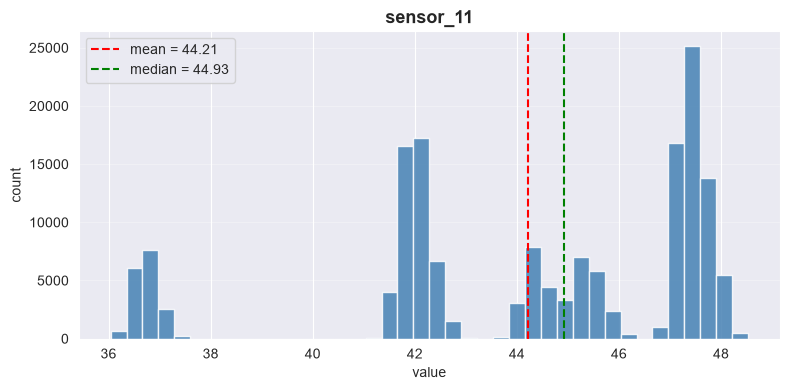

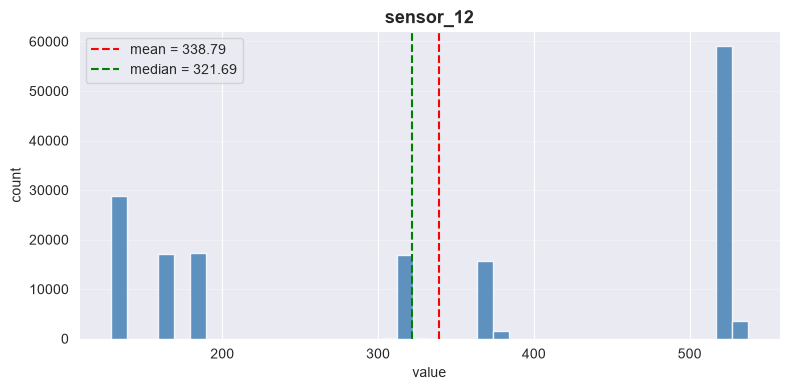

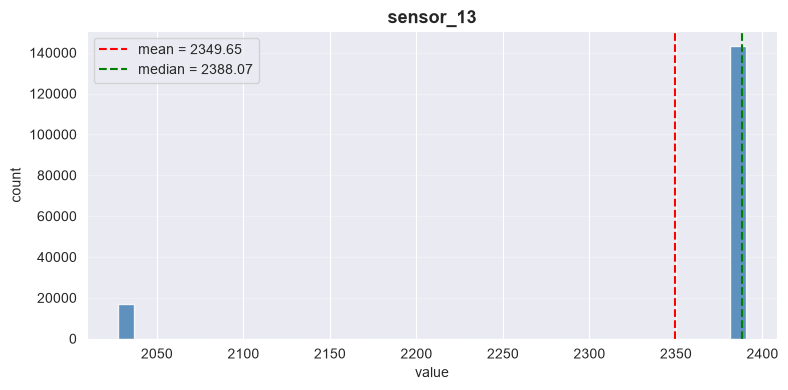

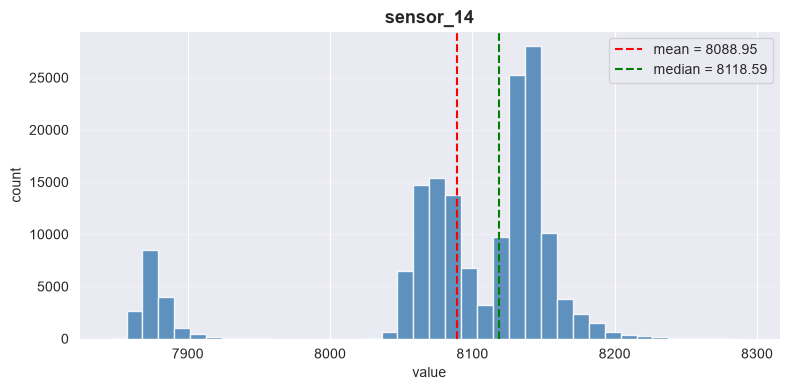

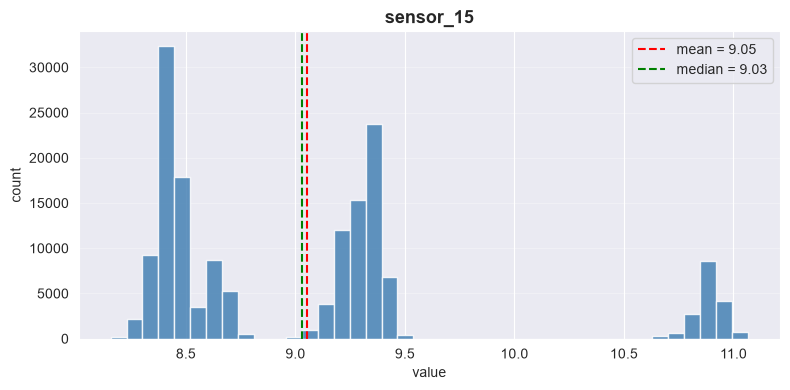

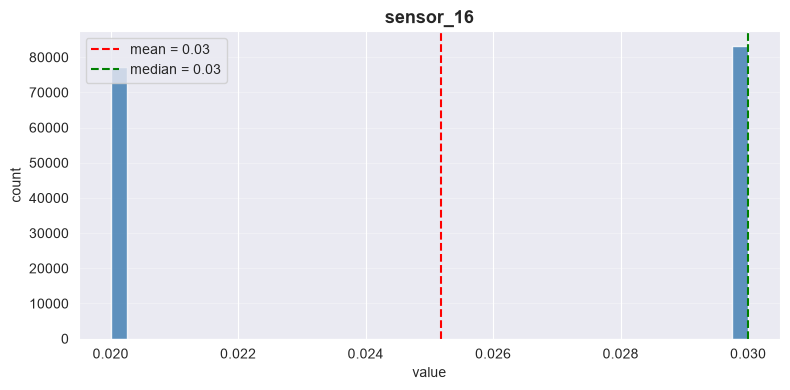

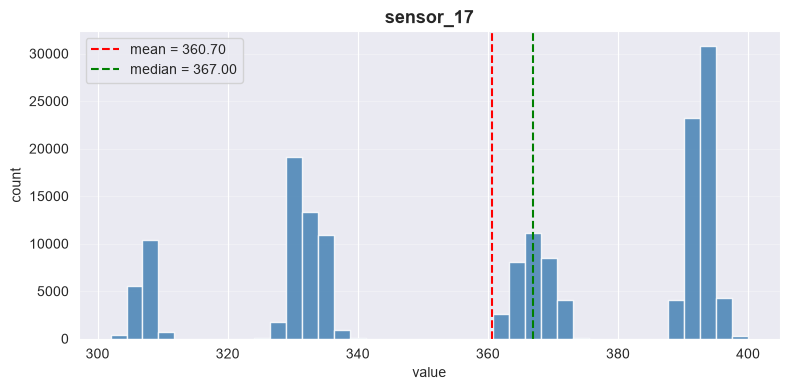

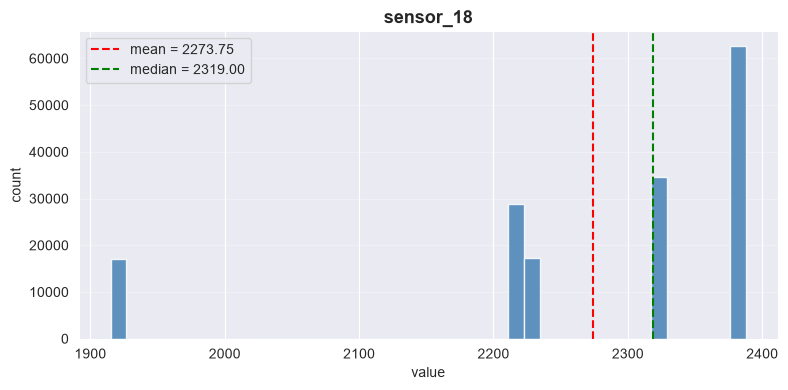

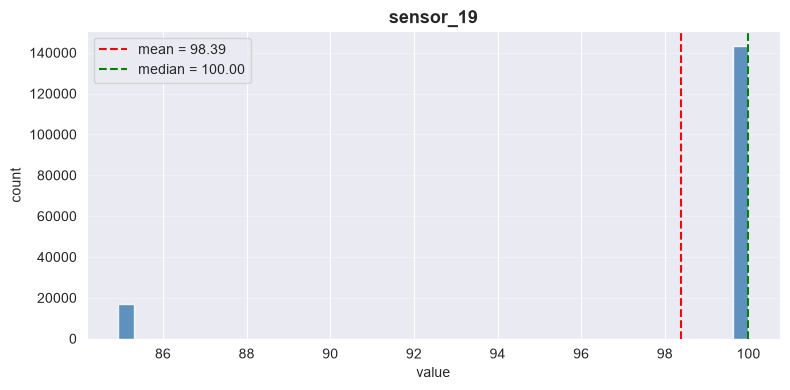

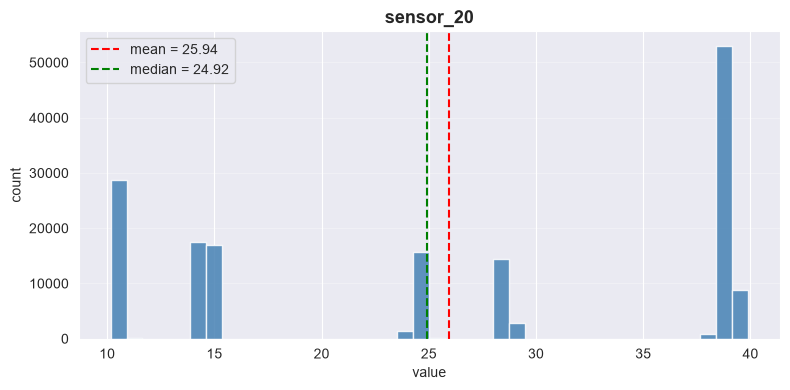

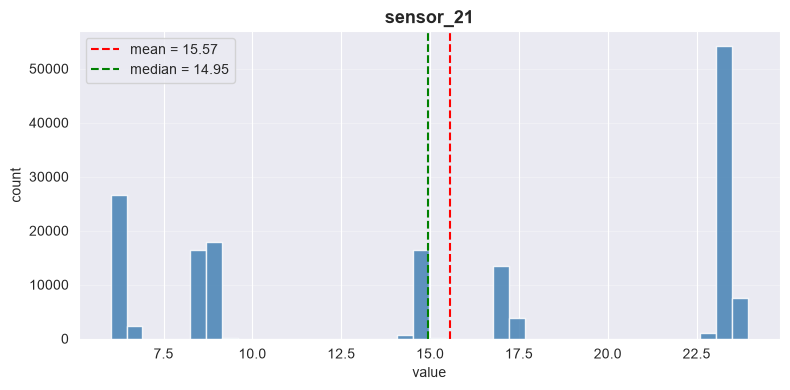

In [146]:
for col in sensor_cols:
  # plt.hist(train_all[col]) #plot every column at one no overlap between columns
  # plt.title(col)
  # plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(train_all[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)

    mean_val = train_all[col].mean()
    median_val = train_all[col].median()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'median = {median_val:.2f}')

    plt.title(col, fontsize=13, fontweight='bold')
    plt.xlabel('value')
    plt.ylabel('count')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

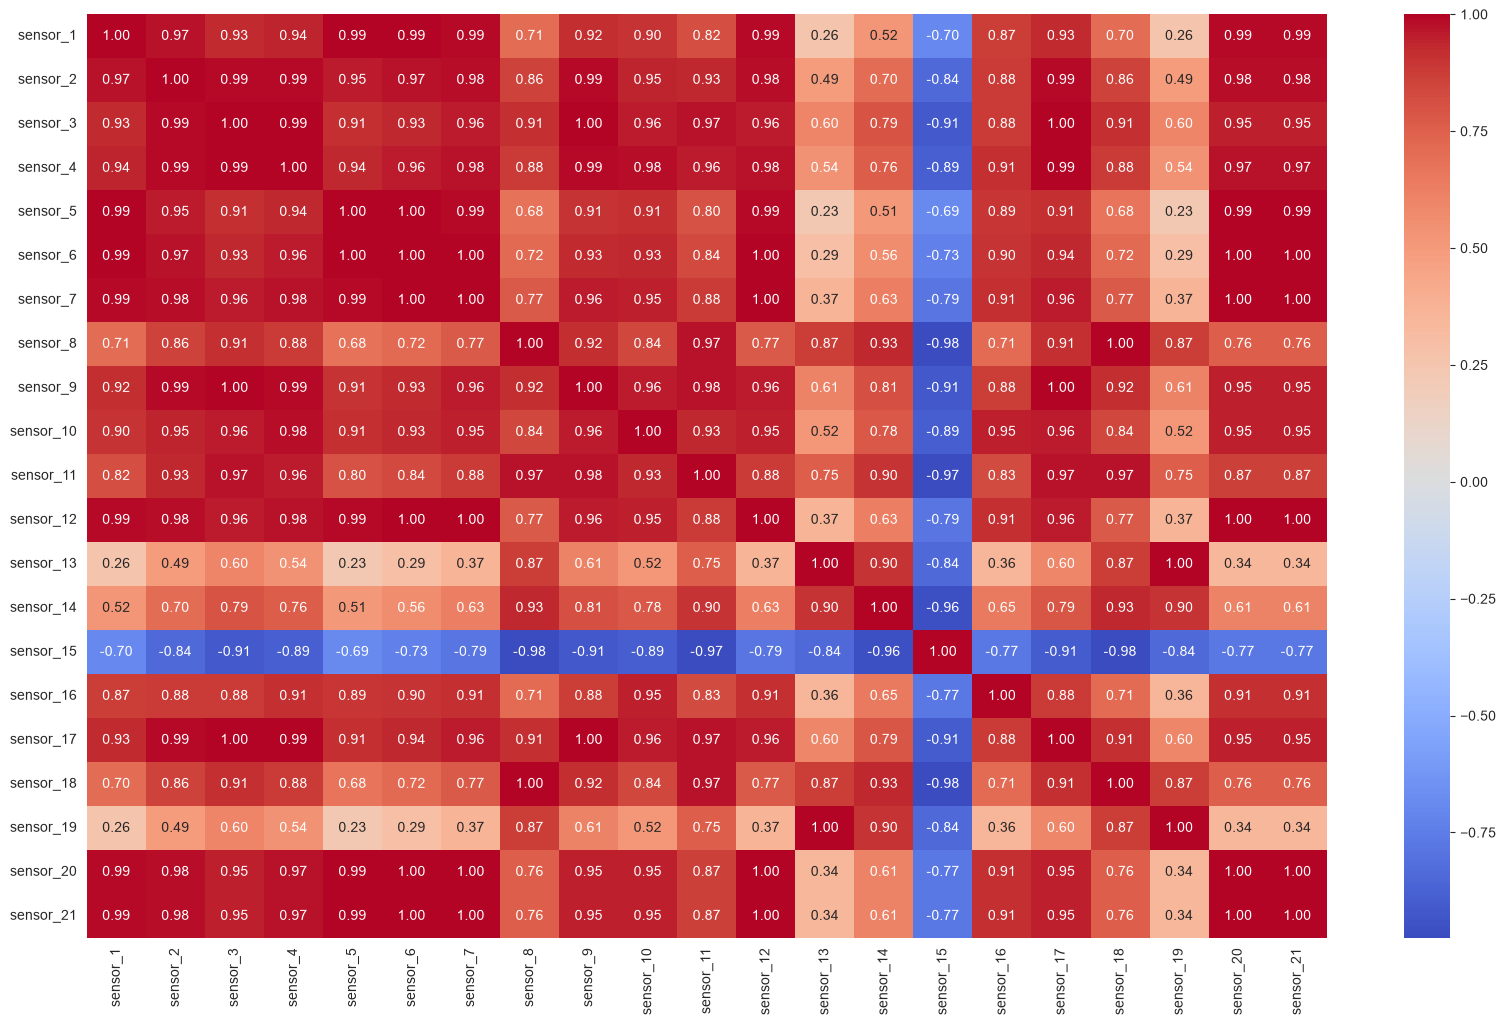

In [147]:
corr = train_all[sensor_cols].corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.show
#missleading because all sensors are operating on same fligh so i should normalize data so i can gain real informations from graphs

In [148]:
train_all

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,125,FD001,1,1,FD001_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,125,FD001,1,1,FD001_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,125,FD001,1,1,FD001_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,125,FD001,1,1,FD001_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,125,FD001,1,1,FD001_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160354,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,372,2319,100.0,29.11,17.5234,4,FD004,6,2,FD004_249
160355,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,396,2388,100.0,39.38,23.7151,3,FD004,6,2,FD004_249
160356,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,395,2388,100.0,39.78,23.8270,2,FD004,6,2,FD004_249
160357,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,337,2223,100.0,15.26,9.0774,1,FD004,6,2,FD004_249


In [149]:
train_all[sensor_cols]=train_all[sensor_cols].astype(float)
test_all[sensor_cols]=test_all[sensor_cols].astype(float)

In [150]:
test_all[sensor_cols]

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.30,...,521.72,2388.03,8125.55,8.4052,0.03,392.0,2388.0,100.0,38.86,23.3735
1,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.30,...,522.16,2388.06,8139.62,8.3803,0.03,393.0,2388.0,100.0,39.02,23.3916
2,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.30,...,521.97,2388.03,8130.10,8.4441,0.03,393.0,2388.0,100.0,39.08,23.4166
3,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.30,...,521.38,2388.05,8132.90,8.3917,0.03,391.0,2388.0,100.0,39.00,23.3737
4,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.30,...,522.15,2388.03,8129.54,8.4031,0.03,390.0,2388.0,100.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104892,445.00,550.30,1364.40,1129.17,3.91,5.72,138.34,2212.35,8351.73,1.02,...,130.87,2388.50,8112.61,9.4427,0.02,331.0,2212.0,100.0,10.53,6.2620
104893,491.19,608.00,1494.75,1260.88,9.35,13.66,334.75,2324.23,8758.69,1.07,...,314.51,2388.33,8086.83,9.2772,0.02,366.0,2324.0,100.0,24.33,14.6486
104894,449.44,555.92,1370.65,1130.97,5.48,8.00,194.92,2223.57,8370.49,1.02,...,182.76,2388.64,8100.84,9.3982,0.02,336.0,2223.0,100.0,14.69,8.8389
104895,491.19,608.19,1489.11,1256.25,9.35,13.66,333.15,2324.19,8753.04,1.07,...,314.17,2388.37,8085.24,9.2727,0.03,366.0,2324.0,100.0,24.44,14.6887


In [151]:
train_all["op_condition"] = 0
test_all["op_condition"] = 0

In [152]:
mask_train_all = train_all["dataset"].isin(["FD002","FD004"])
mask_test_all = test_all["dataset"].isin(["FD002","FD004"])
kmean = KMeans(n_clusters=6,random_state=111,n_init=10)

In [153]:
mask_train_all

0         False
1         False
2         False
3         False
4         False
          ...  
160354     True
160355     True
160356     True
160357     True
160358     True
Name: dataset, Length: 160359, dtype: bool

In [154]:
train_all.loc[mask_train_all, 'op_condition'] = kmean.fit_predict(train_all.loc[mask_train_all, setting_cols])

In [155]:
test_all.loc[mask_test_all, 'op_condition'] = kmean.predict(test_all.loc[mask_test_all, setting_cols])

In [156]:
train_all["dataset"].unique()

<ArrowStringArray>
['FD001', 'FD002', 'FD003', 'FD004']
Length: 4, dtype: str

In [157]:
train_all["op_condition"].unique()

array([0, 5, 2, 1, 3, 4])

In [158]:
scalers = {}  # هيتحفظ فيه كل scaler على حسب (dataset, op_condition)

for fd in train_all["dataset"].unique():
  for cond in train_all["op_condition"].unique():
    train_mask = (train_all['dataset'] == fd) & (train_all['op_condition'] == cond)
    test_mask = (test_all['dataset'] == fd) & (test_all['op_condition'] == cond)

    if train_mask.sum() == 0:
        continue

    scaler = StandardScaler()
    train_all.loc[train_mask, sensor_cols] = scaler.fit_transform(train_all.loc[train_mask, sensor_cols])

    if test_mask.sum() > 0:
        test_all.loc[test_mask, sensor_cols] = scaler.transform(test_all.loc[test_mask, sensor_cols])

    scalers[(fd, cond)] = scaler   # <-- الإضافة المهمة

In [159]:
train_all.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id,op_condition
0,1,1,-0.0007,-0.0004,100.0,0.0,-1.721725,-0.134255,-0.925936,-5.329071e-15,...,0.0,0.0,1.348493,1.194427,125,FD001,1,1,FD001_1,0
1,1,2,0.0019,-0.0003,100.0,0.0,-1.061780,0.211528,-0.643726,-5.329071e-15,...,0.0,0.0,1.016528,1.236922,125,FD001,1,1,FD001_1,0
2,1,3,-0.0043,0.0003,100.0,0.0,-0.661813,-0.413166,-0.525953,-5.329071e-15,...,0.0,0.0,0.739891,0.503423,125,FD001,1,1,FD001_1,0
3,1,4,0.0007,0.0000,100.0,0.0,-0.661813,-1.261314,-0.784831,-5.329071e-15,...,0.0,0.0,0.352598,0.777792,125,FD001,1,1,FD001_1,0
4,1,5,-0.0019,-0.0002,100.0,0.0,-0.621816,-1.251528,-0.301518,-5.329071e-15,...,0.0,0.0,0.463253,1.059552,125,FD001,1,1,FD001_1,0


In [160]:
test_all.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id,op_condition
0,1,1,0.0023,0.0003,100.0,0.0,0.678077,-0.853550,-1.191480,-5.329071e-15,...,0.0,0.0,0.241943,0.774097,125,FD001,1,1,FD001_1,0
1,1,2,-0.0027,-0.0003,100.0,0.0,-1.941707,-0.338137,-1.501467,-5.329071e-15,...,0.0,0.0,1.127183,0.941305,125,FD001,1,1,FD001_1,0
2,1,3,0.0003,0.0001,100.0,0.0,-0.441831,-0.584426,-0.843717,-5.329071e-15,...,0.0,0.0,1.459148,1.172256,125,FD001,1,1,FD001_1,0
3,1,4,0.0042,0.0000,100.0,0.0,-0.481827,-1.044384,-0.279297,-5.329071e-15,...,0.0,0.0,1.016528,0.775945,125,FD001,1,1,FD001_1,0
4,1,5,0.0014,0.0000,100.0,0.0,-0.341839,-0.543650,-0.779276,-5.329071e-15,...,0.0,0.0,0.961200,1.138999,125,FD001,1,1,FD001_1,0


In [161]:
for col in all_cols:
    print(f"{col}: coff_of_var : {(train_all[col].std())/(train_all[col].mean())}")
    print("______________________________")

unit_number: coff_of_var : 0.6903337848598046
______________________________
time_cycles: coff_of_var : 0.677347274547103
______________________________
op_setting_1: coff_of_var : 0.960261108141514
______________________________
op_setting_2: coff_of_var : 0.8974023365720343
______________________________
op_setting_3: coff_of_var : 0.1291107753954873
______________________________
sensor_1: coff_of_var : -9.33884328053695
______________________________
sensor_2: coff_of_var : -31163137198491.78
______________________________
sensor_3: coff_of_var : 364197541702900.44
______________________________
sensor_4: coff_of_var : -164359948615163.56
______________________________
sensor_5: coff_of_var : -2.403690025440268
______________________________
sensor_6: coff_of_var : -2232781015948.5444
______________________________
sensor_7: coff_of_var : -91090544334215.92
______________________________
sensor_8: coff_of_var : 3004364422732.746
______________________________
sensor_9: coff_of_var 

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_18320\2984402800.py:2: RuntimeWarning: invalid value encountered in scalar divide
  print(f"{col}: coff_of_var : {(train_all[col].std())/(train_all[col].mean())}")


In [162]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['sensor'] = sensor_cols
vif_data['VIF'] = [variance_inflation_factor(train_all[sensor_cols].values, i) for i in range(len(sensor_cols))]
print(vif_data.sort_values('VIF', ascending=False))

D:\NTI_project\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


       sensor        VIF
8    sensor_9  12.399044
13  sensor_14  11.473142
12  sensor_13   9.674372
7    sensor_8   9.657873
10  sensor_11   4.255688
14  sensor_15   3.803414
3    sensor_4   3.585703
11  sensor_12   3.166482
6    sensor_7   2.962828
16  sensor_17   2.438184
1    sensor_2   2.208201
2    sensor_3   2.191723
20  sensor_21   1.946647
19  sensor_20   1.937456
9   sensor_10   1.674497
5    sensor_6   1.277146
15  sensor_16   1.046883
4    sensor_5   1.019418
18  sensor_19   1.019183
0    sensor_1   1.000019
17  sensor_18        NaN


In [163]:
dead_sensors = ["sensor_1","sensor_5","sensor_19","sensor_18"]
active_sensors = [sensor for sensor in sensor_cols if sensor not in dead_sensors]

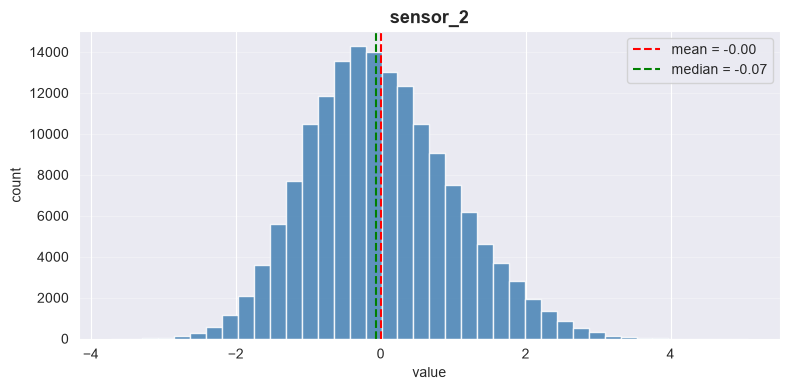

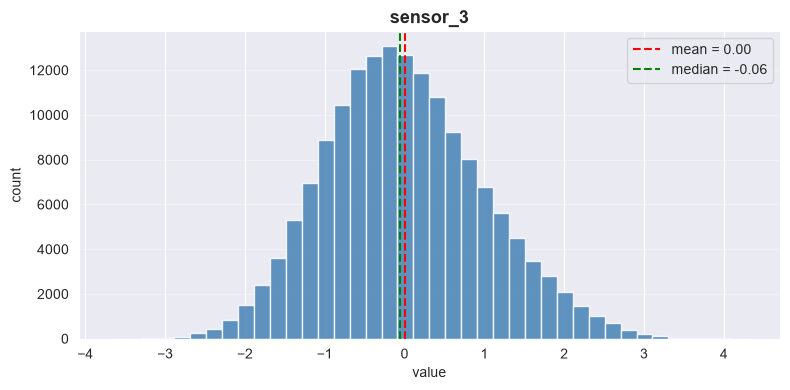

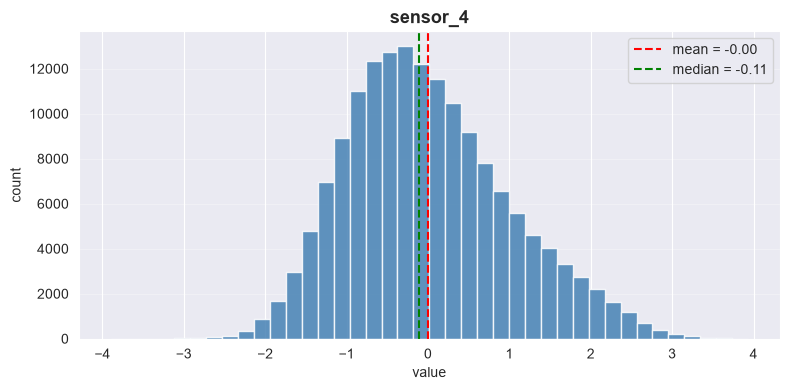

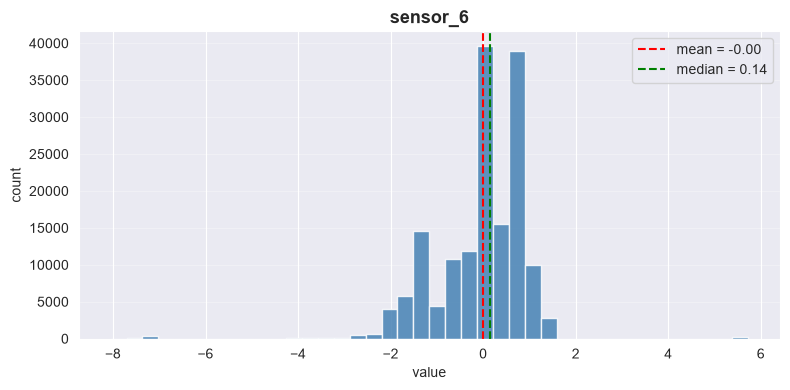

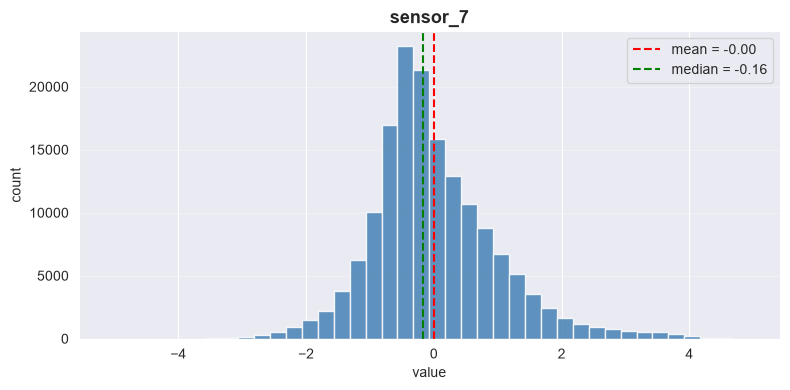

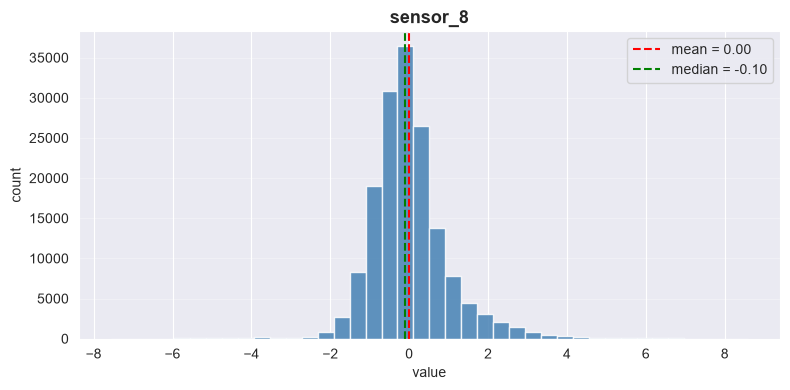

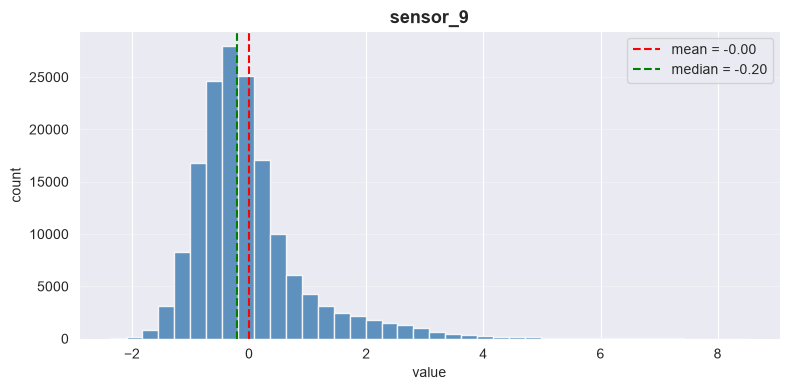

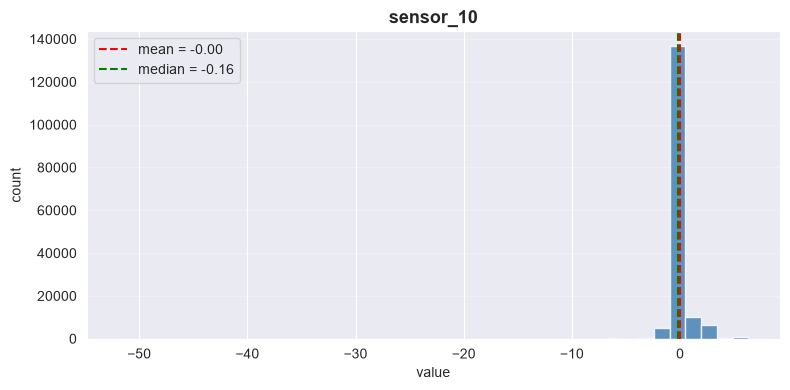

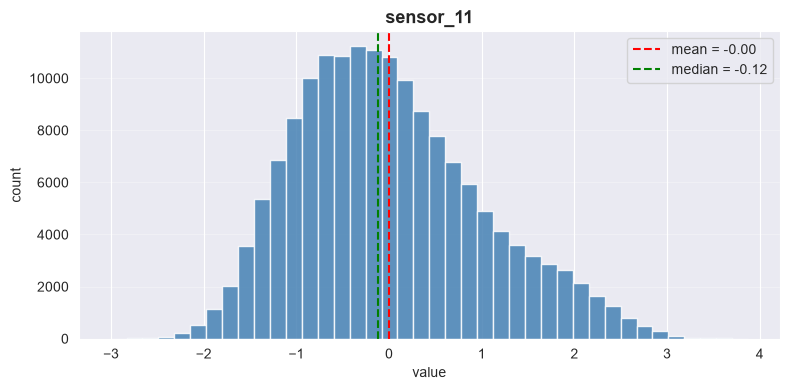

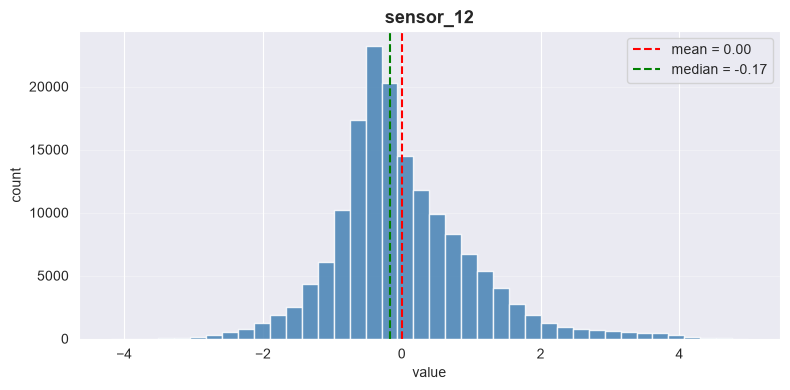

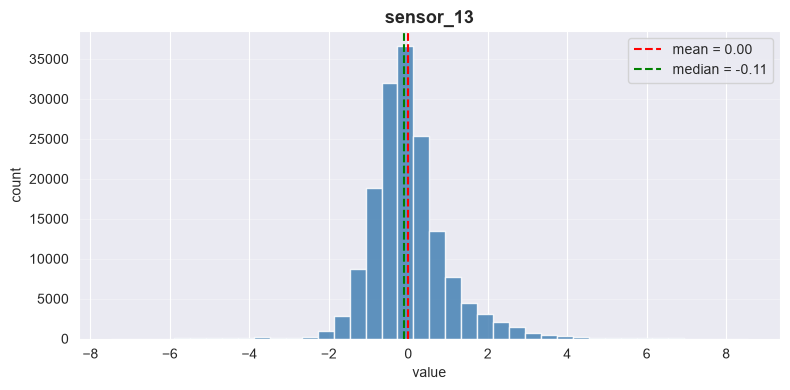

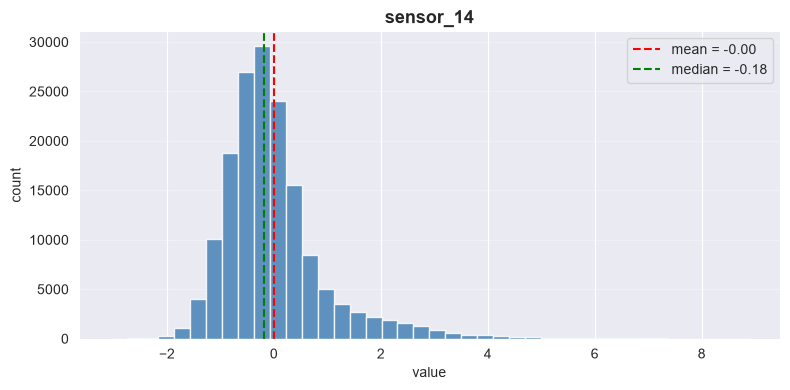

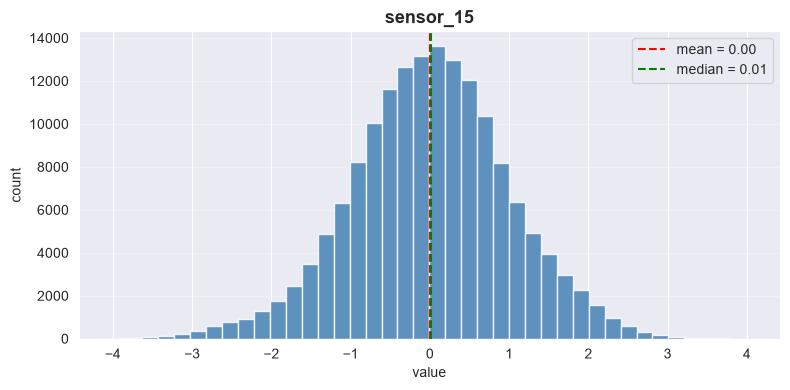

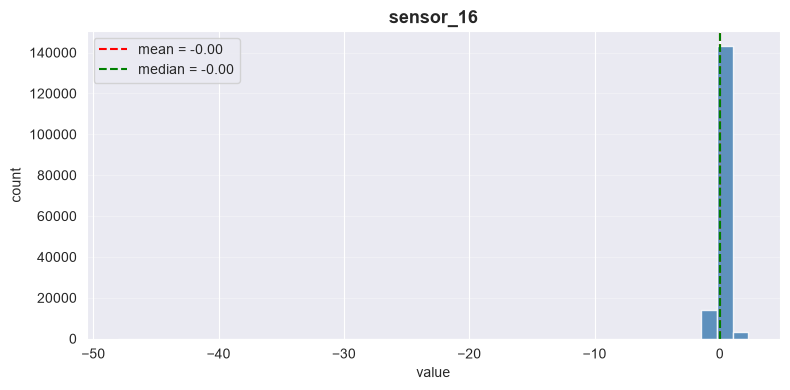

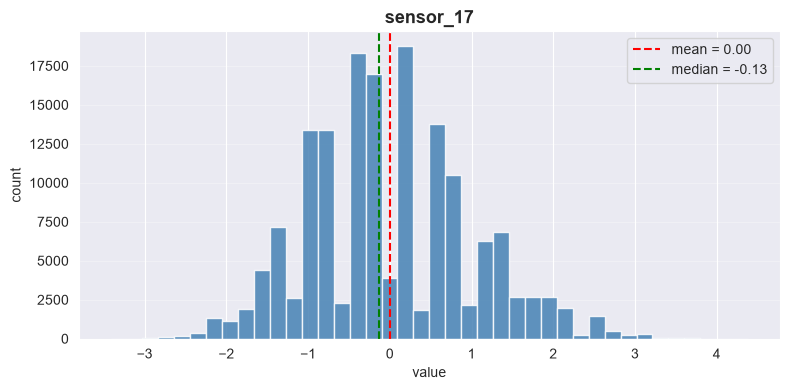

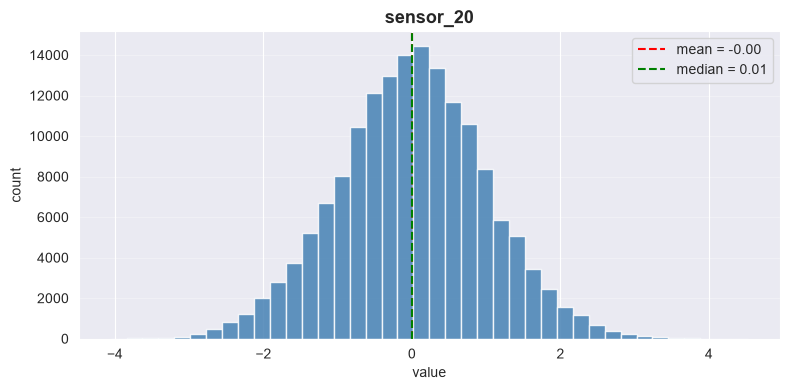

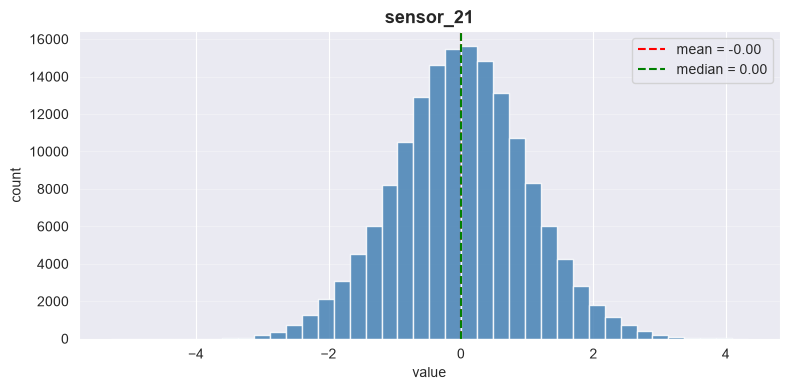

In [164]:
for col in active_sensors:


    plt.figure(figsize=(8, 4))
    plt.hist(train_all[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)

    mean_val = train_all[col].mean()
    median_val = train_all[col].median()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'median = {median_val:.2f}')

    plt.title(col, fontsize=13, fontweight='bold')
    plt.xlabel('value')
    plt.ylabel('count')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [165]:
print(train_all[sensor_cols].skew().sort_values())

sensor_16   -38.621129
sensor_19    -4.134333
sensor_10    -2.387296
sensor_6     -1.659573
sensor_5     -0.260127
sensor_15    -0.100603
sensor_18     0.000000
sensor_20     0.003318
sensor_21     0.010784
sensor_3      0.279851
sensor_2      0.315968
sensor_17     0.317597
sensor_4      0.455285
sensor_11     0.490290
sensor_7      0.805261
sensor_12     0.828232
sensor_8      0.857166
sensor_13     0.859110
sensor_1      1.307873
sensor_14     1.980558
sensor_9      2.062476
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

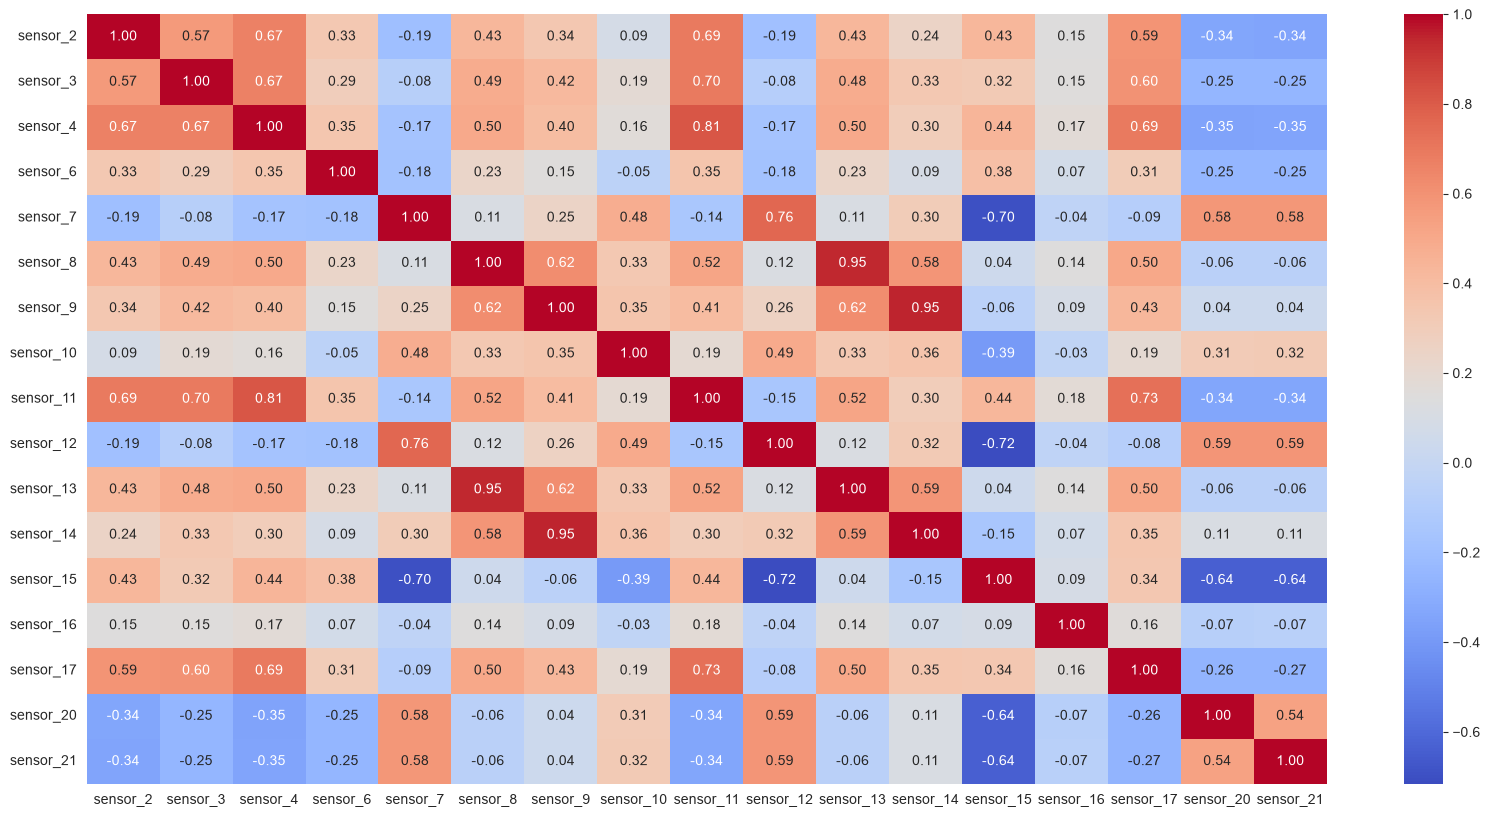

In [166]:
corr = train_all[active_sensors].corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.show

In [167]:
rul_corr = train_all[sensor_cols].corrwith(train_all['rul']).sort_values(ascending=False)
print(rul_corr)

sensor_20    0.272333
sensor_21    0.270129
sensor_7     0.086288
sensor_12    0.086148
sensor_19    0.019371
sensor_5     0.006498
sensor_1    -0.027217
sensor_16   -0.180444
sensor_6    -0.197993
sensor_10   -0.219585
sensor_15   -0.331429
sensor_14   -0.448650
sensor_9    -0.535137
sensor_8    -0.551623
sensor_13   -0.552313
sensor_2    -0.623699
sensor_3    -0.644186
sensor_17   -0.670868
sensor_4    -0.736541
sensor_11   -0.770416
sensor_18         NaN
dtype: float64


D:\NTI_project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\NTI_project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [168]:
# dead_sensors = ["sensor_1","sensor_5","sensor_19","sensor_18"]
# active_sensors = [sensor for sensor in sensor_cols if sensor not in dead_sensors]

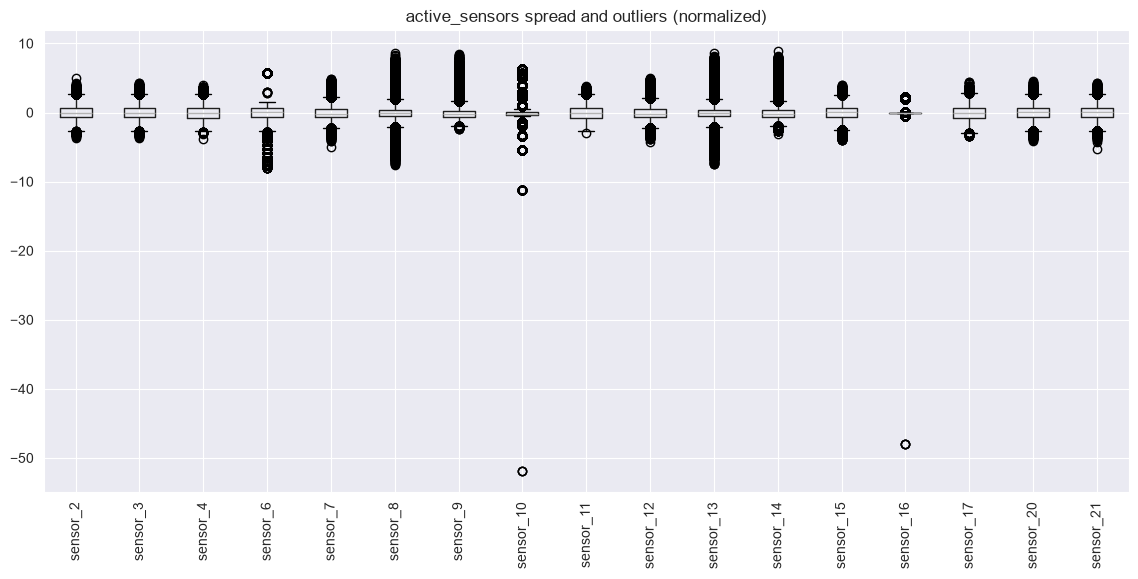

In [169]:
plt.figure(figsize=(14, 6))
train_all[active_sensors].boxplot(rot=90)
plt.title('active_sensors spread and outliers (normalized)')
plt.show()

In [170]:
outlier_indices = []
for col in active_sensors:
  q1 = train_all[col].quantile(0.25)
  q3 = train_all[col].quantile(0.75)
  iqr = 1.5*(q3-q1)
  indices = train_all[(train_all[col]<q1-iqr) | (train_all[col]>q3+iqr)].index  #true outlier
  outlier_indices.extend(indices)

In [171]:
outlier_indices = Counter(outlier_indices)
outlier_indices

Counter({138655: 13,
         118975: 13,
         118978: 13,
         100833: 13,
         96511: 12,
         108760: 12,
         107845: 12,
         111148: 12,
         112407: 12,
         112712: 12,
         120470: 12,
         134395: 12,
         143493: 12,
         148004: 12,
         148005: 12,
         111146: 12,
         139632: 12,
         142134: 12,
         137478: 12,
         137480: 12,
         154603: 12,
         80095: 12,
         144030: 12,
         145134: 12,
         128327: 11,
         77661: 11,
         78764: 11,
         79081: 11,
         79526: 11,
         81195: 11,
         83193: 11,
         83648: 11,
         84733: 11,
         85700: 11,
         86406: 11,
         90287: 11,
         93626: 11,
         100832: 11,
         111145: 11,
         122739: 11,
         122989: 11,
         123003: 11,
         125790: 11,
         134392: 11,
         139248: 11,
         139635: 11,
         143494: 11,
         144880: 11,
      

In [172]:
multiple_outlier = [i for i,v in outlier_indices.items() if v > 12]

In [173]:
multiple_outlier

[138655, 118975, 118978, 100833]

In [174]:
# train_all[train_all["sensor_10"] < -20]
train_all=train_all[train_all["sensor_10"] >= -10]

In [175]:
#train_all=train_all.drop(train_all[train_all["sensor_16"] < -20])
train_all=train_all[train_all["sensor_16"] >= -20]

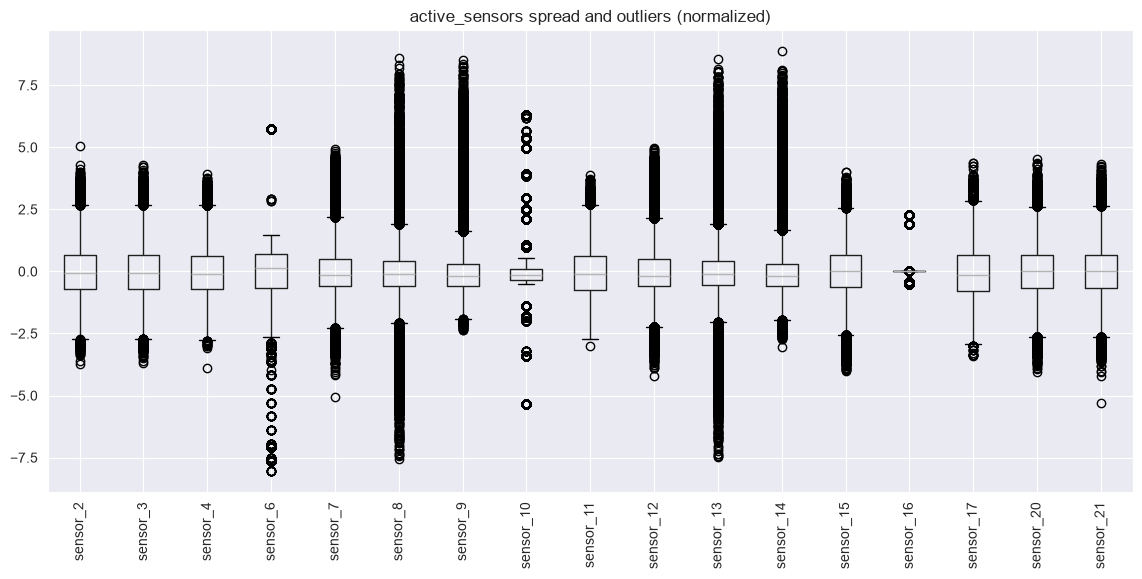

In [176]:
plt.figure(figsize=(14, 6))
train_all[active_sensors].boxplot(rot=90)
plt.title('active_sensors spread and outliers (normalized)')
plt.show()

In [177]:
x_train = train_all[active_sensors]
x_test = test_all[active_sensors]

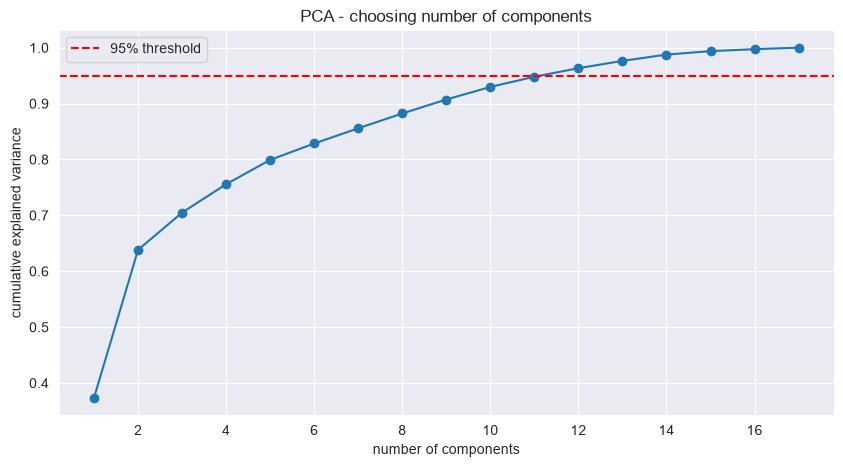

components needed for 95% variance: 12


In [178]:
pca_full = PCA()
pca_full.fit(x_train)

cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title('PCA - choosing number of components')
plt.legend()
plt.grid(True)
plt.show()

# n3rf ay 3dd components ywsl le 95% variance
n_components_95 = np.argmax(cum_variance >= 0.95) + 1
print("components needed for 95% variance:", n_components_95)

In [179]:
# pca_2d = PCA(n_components=2)
# X_pca_2d = pca_2d.fit_transform(x_train)
# #____________________________________________
# pca_3d = PCA(n_components=3)
# X_pca_3d = pca_3d.fit_transform(x_train)
# #____________________________________________
# PCA2_varince_ratio = pca_2d.explained_variance_ratio_
# PCA3_varince_ratio = pca_3d.explained_variance_ratio_

# print(f" variance ratio for pca_2d PC1 {PCA2_varince_ratio[0]*100:.2f} % variance ratio for pca_2d PC2 {PCA2_varince_ratio[1]*100:.2f}% ")
# print(f" total variance captured for pca_2d {np.sum(PCA2_varince_ratio)*100:.2f}")

# print(f" variance ratio for pca_3d PC1 {PCA3_varince_ratio[0]*100:.2f} % variance ratio for pca_3d PC2 {PCA3_varince_ratio[1]*100:.2f}% variance ratio for pca_3d PC3 {PCA3_varince_ratio[2]*100:.2f}% ")
# print(f" total variance captured for pca_3d {np.sum(PCA3_varince_ratio)*100:.2f}")
#____________________________________________
pca_11d = PCA(n_components=11)
x_train_pca_11d = pca_11d.fit_transform(x_train)
x_test_pca_11d = pca_11d.transform(x_test)
PCA11_varince_ratio = pca_11d.explained_variance_ratio_
print(f" total variance captured for pca_11d {np.sum(PCA11_varince_ratio)*100:.2f}")

 total variance captured for pca_11d 94.80


In [180]:
x_train_pca_11d

array([[-2.70206061,  0.91837121, -0.68687171, ...,  0.25943812,
        -0.0781175 ,  0.41206804],
       [-2.124214  ,  0.71084828, -1.0769263 , ..., -0.18343468,
        -0.08895206,  0.29623741],
       [-2.72154091,  0.8924796 , -0.34980091, ..., -1.25999173,
         0.08676172,  0.75573067],
       ...,
       [ 4.32172179,  9.87635557, -2.22422066, ..., -1.17526497,
        -0.2973453 ,  1.05643798],
       [ 3.59105079,  9.9203476 , -1.91057832, ...,  0.21382368,
         0.40344163,  0.41488004],
       [ 4.23042017,  8.529874  , -1.26735169, ..., -0.64673399,
         0.4730887 ,  0.36606504]], shape=(160289, 11))

In [181]:
x_test_pca_11d

array([[-2.51043504,  0.10363577, -0.65375786, ..., -0.74039906,
        -0.06018954, -0.83016959],
       [-2.9928303 ,  1.75887187, -0.76218053, ...,  0.55604417,
        -0.82585702, -0.13256458],
       [-2.0162937 ,  0.72960575, -1.08095044, ...,  0.41369307,
        -0.12927526,  0.06122515],
       ...,
       [ 4.31731245, -0.0761643 ,  1.45359497, ...,  0.13788947,
        -0.89361991, -0.05277246],
       [ 3.76382688, -0.65005657,  0.99510438, ..., -0.47005344,
        -0.84121845,  0.40072673],
       [ 5.07427084, -0.23910505,  1.55991614, ..., -1.0546612 ,
        -0.2305436 , -0.07820047]], shape=(104897, 11))

In [182]:
train_all['is_degrading'] = (train_all['rul'] < 30).astype(int)
test_all['is_degrading'] = (test_all['rul'] < 30).astype(int)

In [183]:
y_stage1 = train_all["is_degrading"].values

In [184]:
y_stage1

array([0, 0, 0, ..., 1, 1, 1], shape=(160289,))

In [185]:
pca_cols = [f"pc{i+1}" for i in range(11)]
train_all[pca_cols] = x_train_pca_11d
test_all[pca_cols] = x_test_pca_11d

In [186]:
test_all.columns

Index(['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2',
       'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21', 'rul', 'dataset', 'n_conditions', 'n_fault_modes',
       'global_unit_id', 'op_condition', 'is_degrading', 'pc1', 'pc2', 'pc3',
       'pc4', 'pc5', 'pc6', 'pc7', 'pc8', 'pc9', 'pc10', 'pc11'],
      dtype='str')

In [187]:
engines_id = train_all['global_unit_id'].unique().tolist()
print(engines_id)

['FD001_1', 'FD001_2', 'FD001_3', 'FD001_4', 'FD001_5', 'FD001_6', 'FD001_7', 'FD001_8', 'FD001_9', 'FD001_10', 'FD001_11', 'FD001_12', 'FD001_13', 'FD001_14', 'FD001_15', 'FD001_16', 'FD001_17', 'FD001_18', 'FD001_19', 'FD001_20', 'FD001_21', 'FD001_22', 'FD001_23', 'FD001_24', 'FD001_25', 'FD001_26', 'FD001_27', 'FD001_28', 'FD001_29', 'FD001_30', 'FD001_31', 'FD001_32', 'FD001_33', 'FD001_34', 'FD001_35', 'FD001_36', 'FD001_37', 'FD001_38', 'FD001_39', 'FD001_40', 'FD001_41', 'FD001_42', 'FD001_43', 'FD001_44', 'FD001_45', 'FD001_46', 'FD001_47', 'FD001_48', 'FD001_49', 'FD001_50', 'FD001_51', 'FD001_52', 'FD001_53', 'FD001_54', 'FD001_55', 'FD001_56', 'FD001_57', 'FD001_58', 'FD001_59', 'FD001_60', 'FD001_61', 'FD001_62', 'FD001_63', 'FD001_64', 'FD001_65', 'FD001_66', 'FD001_67', 'FD001_68', 'FD001_69', 'FD001_70', 'FD001_71', 'FD001_72', 'FD001_73', 'FD001_74', 'FD001_75', 'FD001_76', 'FD001_77', 'FD001_78', 'FD001_79', 'FD001_80', 'FD001_81', 'FD001_82', 'FD001_83', 'FD001_84', 

In [188]:
train_engines, val_engines = train_test_split(engines_id, test_size=0.2, random_state=42)


In [189]:
train_sub = train_all[train_all['global_unit_id'].isin(train_engines)]
val_sub = train_all[train_all['global_unit_id'].isin(val_engines)]

In [190]:
train_sub

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10,pc11
0,1,1,-0.0007,-0.0004,100.0,0.000000e+00,-1.721725,-0.134255,-0.925936,-5.329071e-15,...,0.918371,-0.686872,0.754841,-0.105722,0.102987,0.147167,1.180000,0.259438,-0.078118,0.412068
1,1,2,0.0019,-0.0003,100.0,0.000000e+00,-1.061780,0.211528,-0.643726,-5.329071e-15,...,0.710848,-1.076926,0.675726,0.171055,-0.148424,0.272919,0.964124,-0.183435,-0.088952,0.296237
2,1,3,-0.0043,0.0003,100.0,0.000000e+00,-0.661813,-0.413166,-0.525953,-5.329071e-15,...,0.892480,-0.349801,0.825429,0.062648,0.115647,-0.367886,0.012655,-1.259992,0.086762,0.755731
3,1,4,0.0007,0.0000,100.0,0.000000e+00,-0.661813,-1.261314,-0.784831,-5.329071e-15,...,1.879713,-0.239274,0.881710,0.787490,-0.327535,-0.776196,-0.840394,-0.289938,-0.828265,-0.073456
4,1,5,-0.0019,-0.0002,100.0,0.000000e+00,-0.621816,-1.251528,-0.301518,-5.329071e-15,...,0.673401,-0.548740,0.695094,-0.137715,-0.395659,0.080535,-0.522692,0.619558,-0.287048,0.227609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160354,249,251,9.9998,0.2500,100.0,-1.136868e-13,1.217152,2.502023,0.836519,1.776357e-15,...,9.954033,-1.152765,-1.396167,1.031562,-0.304852,0.578987,0.497289,-0.487847,-0.326698,-0.141063
160355,249,252,0.0028,0.0015,100.0,0.000000e+00,1.794874,1.550836,2.211462,-3.552714e-15,...,8.733122,-1.711492,-2.055786,0.097699,-0.363875,0.021526,-0.819596,-0.267141,-0.650507,0.505967
160356,249,253,0.0029,0.0000,100.0,0.000000e+00,2.300329,2.862963,2.600924,-3.552714e-15,...,9.876356,-2.224221,-1.984033,-0.250246,0.290974,1.380111,0.138022,-1.175265,-0.297345,1.056438
160357,249,254,35.0046,0.8400,100.0,0.000000e+00,0.423343,2.572076,2.305108,-8.881784e-16,...,9.920348,-1.910578,-2.505757,0.186718,0.629291,-0.620002,0.839691,0.213824,0.403442,0.414880


In [191]:
X_train_s1 = train_sub[pca_cols]
y_train_s1 = train_sub['is_degrading']
X_val_s1 = val_sub[pca_cols]
y_val_s1 = val_sub['is_degrading']

# models = {
#     'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
#     'SVM': SVC(class_weight='balanced'),
#     'KNN': KNeighborsClassifier(n_neighbors=5),
#     'Naive Bayes': GaussianNB(),
#     'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
#     'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),  #>best
#     'AdaBoost': AdaBoostClassifier(random_state=42),
#     'Gradient Boosting': GradientBoostingClassifier(random_state=42),
# }

# results = {}
# for name, model in models.items():
#     model.fit(X_train_s1, y_train_s1)
#     preds = model.predict(X_val_s1)
#     print(f"\n--- {name} ---")
#     print(classification_report(y_val_s1, preds, target_names=['healthy', 'degrading']))
#     results[name] = model

In [192]:



# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5, 10],
# }

# best_f1 = 0
# best_params = None
# best_model = None

# for n_estimators in param_grid['n_estimators']:
#     for max_depth in param_grid['max_depth']:
#         for min_samples_split in param_grid['min_samples_split']:

#             model = RandomForestClassifier(
#                 n_estimators=n_estimators,
#                 max_depth=max_depth,
#                 min_samples_split=min_samples_split,
#                 class_weight='balanced',
#                 random_state=42
#             )
#             model.fit(X_train_s1, y_train_s1)
#             preds = model.predict(X_val_s1)

#             f1_degrading = f1_score(y_val_s1, preds, pos_label=1)

#             print(f"n_estimators={n_estimators}, max_depth={max_depth}, "
#                   f"min_samples_split={min_samples_split} -> degrading F1={f1_degrading:.4f}")

#             if f1_degrading > best_f1:
#                 best_f1 = f1_degrading
#                 best_params = (n_estimators, max_depth, min_samples_split)
#                 best_model = model

# print("\nBEST PARAMS:", best_params)
# print("BEST F1 (degrading):", best_f1)
# print("\nFull report for best model:")
# print(classification_report(y_val_s1, best_model.predict(X_val_s1), target_names=['healthy', 'degrading']))

# stage1_model = best_model

In [193]:
#n_estimators=200, max_depth=None, min_samples_split=10

In [194]:
stage1_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

stage1_model.fit(X_train_s1, y_train_s1)

val_preds = stage1_model.predict(X_val_s1)

print(classification_report(val_preds, y_val_s1, target_names=['healthy', 'degrading']))

              precision    recall  f1-score   support

     healthy       0.95      0.99      0.97     25803
   degrading       0.92      0.75      0.83      5218

    accuracy                           0.95     31021
   macro avg       0.94      0.87      0.90     31021
weighted avg       0.95      0.95      0.95     31021



In [195]:
train_sub_degrading = train_sub[train_sub['is_degrading'] == 1]
val_sub_degrading = val_sub[val_sub['is_degrading'] == 1]

X_train_s2 = train_sub_degrading[active_sensors]
y_train_s2 = train_sub_degrading['rul']
X_val_s2 = val_sub_degrading[active_sensors]
y_val_s2 = val_sub_degrading['rul']

print("Stage 2 train rows (degrading only):", len(X_train_s2))
print("Stage 2 val rows (degrading only):", len(X_val_s2))

Stage 2 train rows (degrading only): 16989
Stage 2 val rows (degrading only): 4250


In [196]:


# regressors = {
#     'Linear Regression': LinearRegression(),
#     'SVR': SVR(),
#     'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
#     'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
#     'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
#     'AdaBoost Regressor': AdaBoostRegressor(random_state=42),
#     'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
# }

# for name, model in regressors.items():
#     model.fit(X_train_s2, y_train_s2)
#     preds = model.predict(X_val_s2)
#     rmse = mean_squared_error(y_val_s2, preds) ** 0.5
#     print(f"{name}: RMSE = {rmse:.2f}")

In [197]:
# param_grid_r = {
#     'n_estimators': [200, 300],
#     'max_depth': [None, 20],
#     'min_samples_split': [2, 10],
# }

# best_rmse = float('inf')
# best_params_r = None
# best_model_r = None

# for n_estimators in param_grid_r['n_estimators']:
#     for max_depth in param_grid_r['max_depth']:
#         for min_samples_split in param_grid_r['min_samples_split']:
#             model = RandomForestRegressor(
#                 n_estimators=n_estimators,
#                 max_depth=max_depth,
#                 min_samples_split=min_samples_split,
#                 random_state=42
#             )
#             model.fit(X_train_s2, y_train_s2)
#             preds = model.predict(X_val_s2)
#             rmse = mean_squared_error(y_val_s2, preds) ** 0.5

#             print(f"n_estimators={n_estimators}, max_depth={max_depth}, "
#                   f"min_samples_split={min_samples_split} -> RMSE={rmse:.2f}")

#             if rmse < best_rmse:
#                 best_rmse = rmse
#                 best_params_r = (n_estimators, max_depth, min_samples_split)
#                 best_model_r = model

# print("\nBEST PARAMS:", best_params_r)
# print("BEST RMSE:", best_rmse)

# stage2_model = best_model_r

In [198]:
stage2_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

stage2_model.fit(X_train_s2, y_train_s2)

val_preds_s2 = stage2_model.predict(X_val_s2)
rmse_s2 = mean_squared_error(y_val_s2, val_preds_s2) ** 0.5

print(f"Stage 2 (Random Forest Regressor) Validation RMSE: {rmse_s2:.2f}")

Stage 2 (Random Forest Regressor) Validation RMSE: 5.04


In [199]:

print("=== KMeans: Operating Condition Clustering ===")
print("Input : op_setting_1, op_setting_2, op_setting_3 (raw)")
print("Output: op_condition (cluster label 0-5)\n")
print("Cluster sizes (train, FD002/FD004):")
print(train_all.loc[mask_train_all, 'op_condition'].value_counts().sort_index())
print("\nInertia (lower = tighter clusters):", kmean.inertia_)




=== KMeans: Operating Condition Clustering ===
Input : op_setting_1, op_setting_2, op_setting_3 (raw)
Output: op_condition (cluster label 0-5)

Cluster sizes (train, FD002/FD004):
op_condition
0    17078
1    17213
2    28853
3    17282
4    17313
5    17199
Name: count, dtype: int64

Inertia (lower = tighter clusters): 0.8791250225626898


In [200]:
print("=== PCA: Sensor Compression ===")
print(f"Input : {len(active_sensors)} active sensors")
print(f"Output: {pca_11d.n_components_} principal components")
print(f"Variance retained: {np.sum(pca_11d.explained_variance_ratio_)*100:.2f}%")

=== PCA: Sensor Compression ===
Input : 17 active sensors
Output: 11 principal components
Variance retained: 94.80%


In [201]:
print("=== STAGE 1: RandomForestClassifier ===")
print("Input : 11 PCA components")
print("Output: is_degrading (0 = healthy, 1 = degrading)\n")

print("--- Validation ---")
print(classification_report(y_val_s1, stage1_model.predict(X_val_s1),
                             target_names=['healthy', 'degrading']))

test_all['pred_is_degrading'] = stage1_model.predict(test_all[pca_cols])
print("--- Test set (predicted vs true) ---")
print(classification_report(test_all['is_degrading'], test_all['pred_is_degrading'],
                             target_names=['healthy', 'degrading']))

=== STAGE 1: RandomForestClassifier ===
Input : 11 PCA components
Output: is_degrading (0 = healthy, 1 = degrading)

--- Validation ---
              precision    recall  f1-score   support

     healthy       0.99      0.95      0.97     26771
   degrading       0.75      0.92      0.83      4250

    accuracy                           0.95     31021
   macro avg       0.87      0.94      0.90     31021
weighted avg       0.96      0.95      0.95     31021

--- Test set (predicted vs true) ---
              precision    recall  f1-score   support

     healthy       1.00      0.99      0.99    102482
   degrading       0.57      0.80      0.66      2415

    accuracy                           0.98    104897
   macro avg       0.78      0.89      0.83    104897
weighted avg       0.99      0.98      0.98    104897



In [202]:
print("=== STAGE 2: RandomForestRegressor ===")
print("Input : 17 active sensors (normalized)")
print("Output: predicted RUL (0-125)\n")

val_rmse = mean_squared_error(y_val_s2, stage2_model.predict(X_val_s2)) ** 0.5
print(f"Validation RMSE (true degrading rows): {val_rmse:.2f}")

test_pred_degrading = test_all[test_all['pred_is_degrading'] == 1]
test_preds = stage2_model.predict(test_pred_degrading[active_sensors])
test_rmse = mean_squared_error(test_pred_degrading['rul'], test_preds) ** 0.5
print(f"Test RMSE (model-predicted degrading rows, n={len(test_pred_degrading)}): {test_rmse:.2f}")

=== STAGE 2: RandomForestRegressor ===
Input : 17 active sensors (normalized)
Output: predicted RUL (0-125)

Validation RMSE (true degrading rows): 5.04
Test RMSE (model-predicted degrading rows, n=3409): 22.33


In [203]:
print("=== FULL PIPELINE: Stage 1 -> Stage 2 combined ===")
full_preds = np.where(
    test_all['pred_is_degrading'] == 1,
    stage2_model.predict(test_all[active_sensors]),
    rul_cap
)
rmse_full = mean_squared_error(test_all['rul'], full_preds) ** 0.5
print(f"Full end-to-end Test RMSE (all {len(test_all)} test rows): {rmse_full:.2f}")

=== FULL PIPELINE: Stage 1 -> Stage 2 combined ===
Full end-to-end Test RMSE (all 104897 test rows): 25.51


In [204]:


MODEL_DIR = "../models"  # برة فولدر notebook، جنب data و try.py
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(kmean,        os.path.join(MODEL_DIR, "kmeans_model.pkl"))
joblib.dump(scalers,      os.path.join(MODEL_DIR, "scalers.pkl"))
joblib.dump(pca_11d,      os.path.join(MODEL_DIR, "pca_model.pkl"))
joblib.dump(stage1_model, os.path.join(MODEL_DIR, "stage1_model.pkl"))
joblib.dump(stage2_model, os.path.join(MODEL_DIR, "stage2_model.pkl"))

print("✅ Models saved to", MODEL_DIR)

✅ Models saved to ../models
